# CSC-350 Artificial Intelligence Semester Project (Section E)
## Advanced Time-Series Forecasting using Lorentzian Distance Classification & Kernel Regression

**Instructor:** Engr. Muhammad Irfan Younas Mughal (eMIYM)  
**Group Members:**
1. **Tayyab Mangi** (CMS: 023-24-0118)
2. **Asif Ali Rattar** (CMS: 023-24-0158)

---

In [1]:
# Import standard scientific and plotting libraries
import os
import requests
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Set plotting backend and theme
%matplotlib inline
sns.set_theme(style="whitegrid")

### Part 1: Historical Candlestick Data Acquisition
Fetch historical 5-minute candlestick data of the BTC/USDT spot market from the Binance API using backward endTime pagination. This collects 5,000 candles representing high-frequency market data.

In [2]:
def fetch_binance_klines(symbol="BTCUSDT", interval="5m", limit=1000, end_time=None):
    """
    Fetch a single batch of klines from the Binance API.
    """
    url = "https://api.binance.com/api/v3/klines"
    params = {
        "symbol": symbol,
        "interval": interval,
        "limit": limit
    }
    if end_time:
        params["endTime"] = end_time
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

def fetch_historical_dataset(symbol="BTCUSDT", interval="5m", total_candles=5000):
    """
    Fetch a large historical dataset of klines by looping in batches backwards in time.
    """
    print(f"Fetching {total_candles} candles for {symbol} ({interval}) from Binance...")
    all_klines = []
    current_end = None
    batch_size = 1000
    
    while len(all_klines) < total_candles:
        remaining = total_candles - len(all_klines)
        limit = min(batch_size, remaining)
        
        try:
            klines = fetch_binance_klines(symbol, interval, limit, current_end)
            if not klines:
                break
            
            # Prepend older klines to keep chronological order
            all_klines = klines + all_klines
            
            # Set the next batch end to 1ms before the oldest candle in the current batch
            first_open_time = klines[0][0]
            current_end = first_open_time - 1
            
            print(f"Fetched {len(all_klines)}/{total_candles} candles...")
            time.sleep(0.1)
        except Exception as e:
            print(f"Error fetching data from Binance: {e}")
            break
            
    # Format raw API response into a pandas DataFrame
    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore"
    ]
    df = pd.DataFrame(all_klines[-total_candles:], columns=columns)
    
    # Cast numerical fields to float
    numeric_cols = ["open", "high", "low", "close", "volume"]
    for col in numeric_cols:
        df[col] = df[col].astype(float)
        
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms")
    
    return df

# Execute historical data fetching
df = fetch_historical_dataset(symbol="BTCUSDT", interval="5m", total_candles=5000)
print(f"Successfully compiled dataset: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head()

Fetching 5000 candles for BTCUSDT (5m) from Binance...


Fetched 1000/5000 candles...


Fetched 2000/5000 candles...


Fetched 3000/5000 candles...


Fetched 4000/5000 candles...


Fetched 5000/5000 candles...
Successfully compiled dataset: 5000 rows, 12 columns.


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore
0,2026-05-05 12:30:00,81222.91,81288.88,81212.47,81239.01,73.75978,2026-05-05 12:34:59.999,5992756.13304600,10383,34.49821000,2802903.73026750,0
1,2026-05-05 12:35:00,81239.00,81269.33,81173.20,81269.32,51.99148,2026-05-05 12:39:59.999,4223404.80943370,8607,28.07434000,2280436.49893530,0
2,2026-05-05 12:40:00,81269.31,81307.68,81269.31,81307.68,40.54604,2026-05-05 12:44:59.999,3296012.31584190,6851,22.70567000,1845831.93413370,0
3,2026-05-05 12:45:00,81307.68,81312.39,81192.29,81238.54,54.21752,2026-05-05 12:49:59.999,4405440.19416540,9365,14.99613000,1218378.12840980,0
4,2026-05-05 12:50:00,81238.54,81329.61,81222.40,81318.96,94.46191,2026-05-05 12:54:59.999,7679862.83500690,6571,61.85641000,5029362.41186470,0


### Part 2: Feature Engineering & Technical Indicators
We construct the technical indicator feature space:
1. **RSI (9 and 14 periods)**: Relative Strength Index to identify overbought/oversold momentum.
2. **WaveTrend (10, 11 periods)**: A classic technical oscillator for cyclic trend exhaustions.
3. **CCI (20 period)**: Commodity Channel Index to measure price deviation from statistical means.
4. **ADX (14 period)**: Average Directional Index to quantify trend strength.
5. **Nadaraya-Watson Kernel Regression**: A causal (non-repainting) Nadaraya-Watson filter using a Rational Quadratic Kernel to estimate local smooth trends.

In [3]:
def ema(series, period):
    return series.ewm(span=period, adjust=False).mean()

def sma(series, period):
    return series.rolling(window=period).mean()

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period-1, adjust=False).mean()
    avg_loss = loss.ewm(com=period-1, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    return 100 - (100 / (1 + rs))

def calculate_wavetrend(high, low, close, n1=10, n2=11):
    ap = (high + low + close) / 3
    esa = ema(ap, n1)
    d = ema((ap - esa).abs(), n1)
    ci = (ap - esa) / (0.015 * d + 1e-10)
    wt1 = ema(ci, n2)
    wt2 = sma(wt1, 4)
    return wt1, wt2

def calculate_cci(high, low, close, period=20):
    tp = (high + low + close) / 3
    tp_sma = sma(tp, period)
    mad = tp.rolling(window=period).apply(
        lambda x: np.mean(np.abs(x - np.mean(x))), raw=True
    )
    return (tp - tp_sma) / (0.015 * mad + 1e-10)

def calculate_adx(high, low, close, period=14):
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    
    up_move = high.diff()
    down_move = low.shift(1) - low
    
    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)
    
    plus_dm = pd.Series(plus_dm, index=close.index)
    minus_dm = pd.Series(minus_dm, index=close.index)
    
    atr = tr.ewm(com=period-1, adjust=False).mean()
    plus_di = 100 * plus_dm.ewm(com=period-1, adjust=False).mean() / (atr + 1e-10)
    minus_di = 100 * minus_dm.ewm(com=period-1, adjust=False).mean() / (atr + 1e-10)
    
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-10)
    return dx.ewm(com=period-1, adjust=False).mean()

def nadaraya_watson_rational_quadratic(close, h=8, r=8.0, lookback=25):
    weights = np.zeros(lookback)
    for i in range(lookback):
        weights[i] = (1 + (i**2) / (2 * r * (h**2)))**(-r)
        
    weights_sum = np.sum(weights)
    result = np.zeros(len(close))
    close_arr = close.values
    
    for t in range(len(close)):
        if t < lookback - 1:
            result[t] = close_arr[t]
        else:
            window = close_arr[t - lookback + 1 : t + 1][::-1]
            result[t] = np.sum(window * weights) / weights_sum
            
    return pd.Series(result, index=close.index)

### Part 3: Custom Lorentzian Classifier & Feature Preparation
We construct the custom **Lorentzian Distance KNN Classifier**.
Unlike Euclidean distance, which computes straight-line distance, the Lorentzian distance applies a logarithmic warp to feature space differences:
$$d(x, y) = \sum_{i=1}^{D} \ln(1 + |x_i - y_i|)$$
This classification technique is highly robust to indicators exhibiting heavy-tailed distributions and anomalous outlier spikes.

In [4]:
def lorentzian_distance(x, y):
    """
    Custom Lorentzian distance metric.
    Calculates logarithmic warping of coordinates to dampen outlier impacts.
    """
    return np.sum(np.log(1 + np.abs(x - y)))

def prepare_features_and_targets(df, target_horizon=1, threshold=0.0):
    df = df.copy()
    
    # Calculate indicators
    df["f1_rsi"] = calculate_rsi(df["close"], period=14)
    wt1, wt2 = calculate_wavetrend(df["high"], df["low"], df["close"], n1=10, n2=11)
    df["f2_wt"] = wt1
    df["f3_cci"] = calculate_cci(df["high"], df["low"], df["close"], period=20)
    df["f4_adx"] = calculate_adx(df["high"], df["low"], df["close"], period=14)
    df["f5_rsi_short"] = calculate_rsi(df["close"], period=9)
    
    # Trend confirmation
    df["kernel_reg"] = nadaraya_watson_rational_quadratic(df["close"], h=8, r=8.0, lookback=25)
    df["kernel_slope"] = df["kernel_reg"].diff()
    
    # Target Labeling: Classify 1 (Up) if return > threshold, else -1 (Down/Flat)
    future_change = (df["close"].shift(-target_horizon) - df["close"]) / df["close"]
    df["target"] = np.where(future_change > threshold, 1, -1)
    
    df_clean = df.dropna().copy()
    
    feature_cols = ["f1_rsi", "f2_wt", "f3_cci", "f4_adx", "f5_rsi_short"]
    X = df_clean[feature_cols].values
    y = df_clean["target"].values
    
    return df_clean, X, y

df_clean, X, y = prepare_features_and_targets(df, target_horizon=1, threshold=0.0)
print(f"Prepared feature matrix X shape: {X.shape}")
print(f"Prepared target vector y shape: {y.shape}")
print(f"Class distributions: {pd.Series(y).value_counts().to_dict()} (-1: Down/Flat, 1: Up)")

Prepared feature matrix X shape: (4981, 5)
Prepared target vector y shape: (4981,)
Class distributions: {-1: 2494, 1: 2487} (-1: Down/Flat, 1: Up)


### Part 4: Train-Test Split & Classifier Pipeline
We execute an 80-20 chronological split to preserve time-series ordering and prevent temporal data leakage. Features are scaled using `RobustScaler` to ensure technical indicator outliers do not distort the distance metrics.
We train and evaluate:
1. **Logistic Regression** (Linear baseline)
2. **Random Forest** (Tree-based ensemble baseline)
3. **Euclidean KNN** (Standard distance-based baseline)
4. **Lorentzian KNN** (Our custom proposed physical distance metric KNN)

In [5]:
# Chronological 80-20 split
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Fit and transform robust scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train models
print("Training models...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

knn_euclidean = KNeighborsClassifier(n_neighbors=9, metric="euclidean")
knn_euclidean.fit(X_train_scaled, y_train)

knn_lorentzian = KNeighborsClassifier(n_neighbors=9, metric=lorentzian_distance)
knn_lorentzian.fit(X_train_scaled, y_train)

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Euclidean KNN": knn_euclidean,
    "Lorentzian KNN": knn_lorentzian
}

# Print test accuracies
print("\n" + "="*35)
print("        TEST SET ACCURACIES")
print("="*35)
predictions = {}
for name, model in models.items():
    preds = model.predict(X_test_scaled)
    acc = np.mean(preds == y_test)
    predictions[name] = preds
    print(f"{name:<20} Accuracy: {acc:.4f}")
print("="*35)

Training models...



        TEST SET ACCURACIES
Logistic Regression  Accuracy: 0.4885
Random Forest        Accuracy: 0.5095
Euclidean KNN        Accuracy: 0.4995


Lorentzian KNN       Accuracy: 0.5196


### Part 5: Model Evaluation (Metrics & Plots)
We evaluate the custom Lorentzian KNN against the baseline models. We plot:
1. The **Classification Report** for detailed precision, recall, and F1-score analysis.
2. The **Confusion Matrix** to inspect true versus predicted positives and negatives.
3. **ROC-AUC Curves** to compare multi-model probability discrimination capacities.

--- Lorentzian KNN Classification Report ---
              precision    recall  f1-score   support

   Down/Flat       0.51      0.51      0.51       489
          Up       0.53      0.53      0.53       508

    accuracy                           0.52       997
   macro avg       0.52      0.52      0.52       997
weighted avg       0.52      0.52      0.52       997



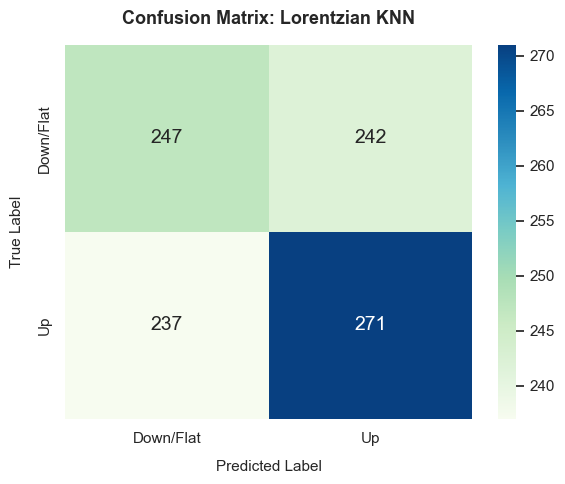

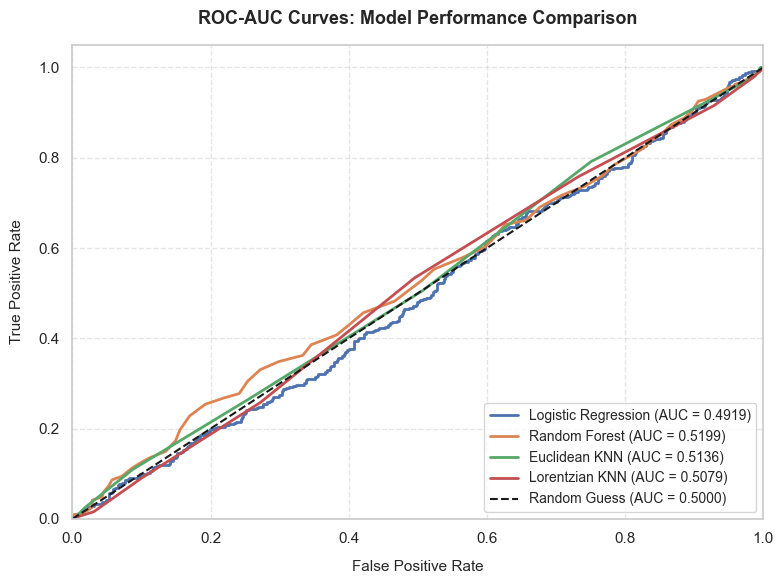

In [6]:
# 1. Classification Report
print("--- Lorentzian KNN Classification Report ---")
print(classification_report(y_test, predictions["Lorentzian KNN"], target_names=["Down/Flat", "Up"]))

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predictions["Lorentzian KNN"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="GnBu", 
            xticklabels=["Down/Flat", "Up"], yticklabels=["Down/Flat", "Up"], 
            annot_kws={"size": 14})
plt.title("Confusion Matrix: Lorentzian KNN", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Predicted Label", fontsize=11, labelpad=10)
plt.ylabel("True Label", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

# 3. ROC-AUC Curves comparison
plt.figure(figsize=(8, 6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probs, pos_label=1.0)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})", linewidth=2)
        
plt.plot([0, 1], [0, 1], "k--", label="Random Guess (AUC = 0.5000)", linewidth=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=11, labelpad=10)
plt.ylabel("True Positive Rate", fontsize=11, labelpad=10)
plt.title("ROC-AUC Curves: Model Performance Comparison", fontsize=13, fontweight="bold", pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Part 6: Fee-Adjusted Trading Backtest
To assess real-world viability, we construct a trading backtest:
- **Signal**: Go Long (+1) when predicted Up, or Short (-1) when predicted Down/Flat.
- **Fees**: Apply a standard exchange transaction fee of **0.05%** per trade execution (whenever the model signals a position change).
- **Comparison**: Compare the cumulative equity curve of our Lorentzian KNN net strategy against the benchmark Buy & Hold BTC returns.

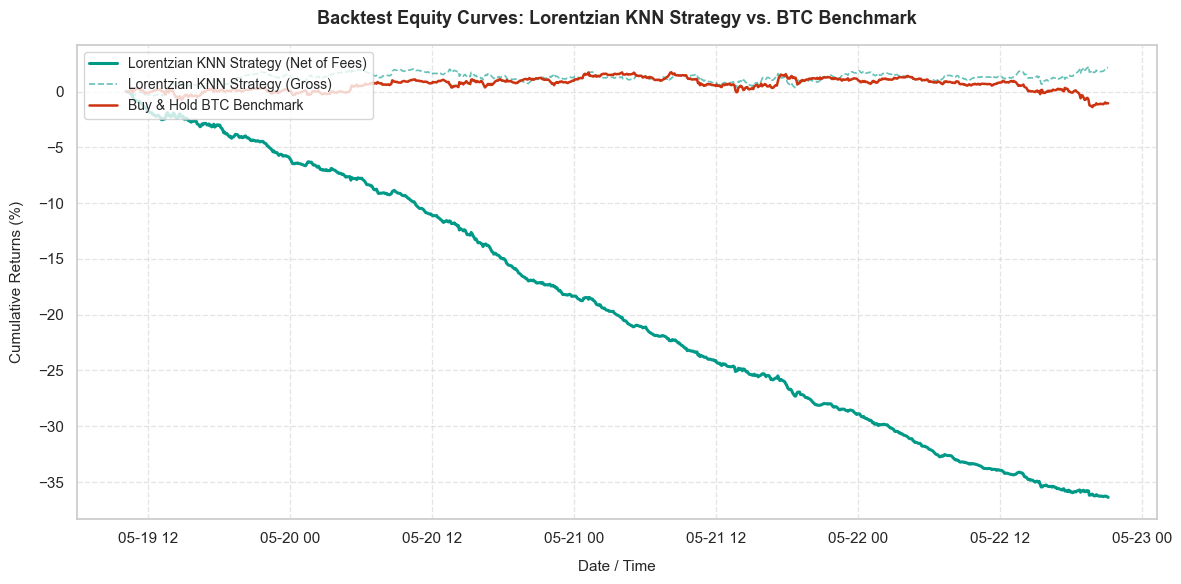


          STRATEGY BACKTEST RESULTS
Buy & Hold BTC Benchmark Return: -1.06%
Lorentzian Strategy Return (Gross):   2.13%
Lorentzian Strategy Return (Net):     -36.37%
Scaler and best model saved to model/ folder successfully!


In [7]:
test_df = df_clean.iloc[split_idx:].copy()
test_df["returns"] = test_df["close"].pct_change()
test_df["signal"] = predictions["Lorentzian KNN"]

# Backtest return calculations
test_df["strategy_returns"] = test_df["signal"].shift(1) * test_df["returns"]

# Subtract transaction fees (0.05% per position change)
position_changes = test_df["signal"].diff().abs()
transaction_fee = 0.0005  # 0.05%
test_df["strategy_returns_net"] = test_df["strategy_returns"] - (position_changes * transaction_fee).fillna(0)

# Cumulative returns calculations
test_df["cum_returns_bh"] = (1 + test_df["returns"].fillna(0)).cumprod() - 1
test_df["cum_returns_strategy_gross"] = (1 + test_df["strategy_returns"].fillna(0)).cumprod() - 1
test_df["cum_returns_strategy_net"] = (1 + test_df["strategy_returns_net"].fillna(0)).cumprod() - 1

# Plot backtesting equity curves
plt.figure(figsize=(12, 6))
plt.plot(test_df["close_time"], test_df["cum_returns_strategy_net"] * 100, 
         label="Lorentzian KNN Strategy (Net of Fees)", color="#009988", linewidth=2.2)
plt.plot(test_df["close_time"], test_df["cum_returns_strategy_gross"] * 100, 
         label="Lorentzian KNN Strategy (Gross)", color="#009988", linestyle="--", alpha=0.6, linewidth=1.2)
plt.plot(test_df["close_time"], test_df["cum_returns_bh"] * 100, 
         label="Buy & Hold BTC Benchmark", color="#CC3311", linewidth=1.8)

plt.title("Backtest Equity Curves: Lorentzian KNN Strategy vs. BTC Benchmark", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Date / Time", fontsize=11, labelpad=10)
plt.ylabel("Cumulative Returns (%)", fontsize=11, labelpad=10)
plt.legend(loc="upper left", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Print terminal statistics
final_bh = test_df["cum_returns_bh"].iloc[-1] * 100
final_gross = test_df["cum_returns_strategy_gross"].iloc[-1] * 100
final_net = test_df["cum_returns_strategy_net"].iloc[-1] * 100

print("\n" + "="*45)
print("          STRATEGY BACKTEST RESULTS")
print("="*45)
print(f"Buy & Hold BTC Benchmark Return: {final_bh:.2f}%")
print(f"Lorentzian Strategy Return (Gross):   {final_gross:.2f}%")
print(f"Lorentzian Strategy Return (Net):     {final_net:.2f}%")
print("="*45)

# Save scaler and best model to disk for packaging
os.makedirs("model", exist_ok=True)
with open(os.path.join("model", "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
with open(os.path.join("model", "lorentzian_knn_model.pkl"), "wb") as f:
    pickle.dump(knn_lorentzian, f)
print("Scaler and best model saved to model/ folder successfully!")

# Save backtest results to csv for verification
os.makedirs("results", exist_ok=True)
test_df.to_csv(os.path.join("results", "backtest_results.csv"), index=False)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="GnBu", 
            xticklabels=["Down/Flat", "Up"], yticklabels=["Down/Flat", "Up"], 
            annot_kws={"size": 14})
plt.title("Confusion Matrix: Lorentzian KNN", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Predicted Label", fontsize=11, labelpad=10)
plt.ylabel("True Label", fontsize=11, labelpad=10)
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=300)
plt.close()

plt.figure(figsize=(8, 6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probs, pos_label=1.0)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random Guess (AUC = 0.5000)", linewidth=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=11, labelpad=10)
plt.ylabel("True Positive Rate", fontsize=11, labelpad=10)
plt.title("ROC-AUC Curves: Model Performance Comparison", fontsize=13, fontweight="bold", pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("results/roc_auc_curve.png", dpi=300)
plt.close()

plt.figure(figsize=(12, 6))
plt.plot(test_df["close_time"], test_df["cum_returns_strategy_net"] * 100, 
         label="Lorentzian KNN Strategy (Net of Fees)", color="#009988", linewidth=2.2)
plt.plot(test_df["close_time"], test_df["cum_returns_strategy_gross"] * 100, 
         label="Lorentzian KNN Strategy (Gross)", color="#009988", linestyle="--", alpha=0.6, linewidth=1.2)
plt.plot(test_df["close_time"], test_df["cum_returns_bh"] * 100, 
         label="Buy & Hold BTC Benchmark", color="#CC3311", linewidth=1.8)
plt.title("Backtest Equity Curves: Lorentzian KNN Strategy vs. BTC Benchmark", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Date / Time", fontsize=11, labelpad=10)
plt.ylabel("Cumulative Returns (%)", fontsize=11, labelpad=10)
plt.legend(loc="upper left", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("results/equity_curve.png", dpi=300)
plt.close()